In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Paper:
    def __init__(self, publication: str, authors: list, year: int, publication_venue: str, citations: list, abstract: str):
        self.publication = publication
        self.authors = authors
        self.year = year
        self.publication_venue = publication_venue
        self.citations = citations
        self.abstract = abstract


In [3]:
papers = {}
index = 0

with open("AP_train.txt") as file:
    for line in file:
        if line.startswith("#index"):
            # to avoid entering the first record before its parsed
            if index != 0:
                papers[index] = Paper(publication, authors, year, publication_venue, citations, abstract)
            # reading index and re-setting other values
            index = int(line.strip().split()[1])
            publication = ''
            authors = []
            year = None
            publication_venue = ''
            citations = []
            abstract = ''

        # setting the publication
        elif line.startswith("#*"):
            publication = line[2:].strip()

        # setting the authors
        elif line.startswith("#@"):
            authors=line[2:].strip().split(';')

        # setting the year
        elif line.startswith("#t"):
            try:
                year = int(line.strip().split()[1])
            except:
                year = None
        
        # setting the publication venue
        elif line.startswith("#c"):
            publication_venue = line[2:].strip()

        # setting the citations
        elif line.startswith("#%"):
            citations.append(line.strip().split()[1])

        # setting the abstract
        elif line.startswith("#!"):
            abstract = line[2:].strip()
            
    #save the last line        
    if index != 0:
        papers[index] = Paper(publication, authors, year,
                              publication_venue, citations, abstract)
     

In [4]:
# Converting the read dict into a dataframe
rows = []
for pid, paper in papers.items():
    rows.append({
        "id": pid,
        "publication": paper.publication,
        "authors": paper.authors,
        "year": paper.year,
        "publication_venue": paper.publication_venue,
        "citations": paper.citations,
        "abstract": paper.abstract
    })
df_papers = pd.DataFrame(rows)
print(df_papers.count())

id                   1976815
publication          1976815
authors              1976815
year                 1976677
publication_venue    1976815
citations            1976815
abstract             1976815
dtype: int64


# 3.1 a. Compute the total number of distinct authors, publications and citations

In [5]:
# get total papers and publications
count_papers = df_papers['id'].nunique()
count_publications = df_papers['publication'].nunique()
print(f"Total papers = {count_papers} \nunique_publications = {count_publications}")

Total papers = 1976815 
unique_publications = 1929487


In [6]:
# unique authors
unique_authors = set()
for authors in df_papers['authors'].dropna():
    for a in authors:
        unique_authors.add(a)
count_authors = len(unique_authors)
print(f"Total Authors: {count_authors}")

Total Authors: 1483290


In [7]:
# unique publication_venues
count_publicationVenues = df_papers['publication_venue'].nunique()
print(f"Total publication venues = {count_publicationVenues}")

Total publication venues = 255686


In [8]:
# unique citations
unique_citations = set()
for citations in df_papers['citations'].dropna():
    for c in citations:
        unique_citations.add(c)
count_citations = len(unique_citations)
print(f"Total Citations: {count_citations}")

Total Citations: 871089


# 3.1 b. Check if this is correct

In [9]:
bool_series = df_papers['publication_venue'].str.contains("Principles and Practice of Knowledge Discovery in Databases|PKDD", case=False, na=False)
venues = df_papers.loc[bool_series, 'publication_venue'].unique()
print(venues)

["PKDD '97 Proceedings of the First European Symposium on Principles of Data Mining and Knowledge Discovery"
 "PKDD '98 Proceedings of the Second European Symposium on Principles of Data Mining and Knowledge Discovery"
 "PKDD '99 Proceedings of the Third European Conference on Principles of Data Mining and Knowledge Discovery"
 "PKDD '00 Proceedings of the 4th European Conference on Principles of Data Mining and Knowledge Discovery"
 "PKDD '01 Proceedings of the 5th European Conference on Principles of Data Mining and Knowledge Discovery"
 "PKDD '02 Proceedings of the 6th European Conference on Principles of Data Mining and Knowledge Discovery"
 "PKDD '04 Proceedings of the 8th European Conference on Principles and Practice of Knowledge Discovery in Databases"
 'Knowledge Discovery in Databases: PKDD 2006: 10th European Conference on Principles and Practice of Knowledge Discovery in Databases, Berlin, Germany, September ... (Lecture Notes in Computer Science)'
 'Knowledge Discovery in 

## So our observation is that even though they show up distinct in our calculation, 
## In reality they are the same conferences and same conference can be written slightly differently
## which means the distinct count is a rough estimate but there are nuances to data. We will have to
## throughly clean it to remove overestimation

# 3.2 a. Publication per author histogram

In [11]:
# get author and publication data and remove blank authors
df_publication_author = df_papers[['id', 'authors', 'publication']].explode('authors')
df_publication_author = df_publication_author[df_publication_author['authors'].str.strip() != '']

In [12]:
# map each author to a list of the publications
publications_per_author = df_publication_author.groupby('authors', as_index=False).agg({'id': lambda x: list(set(x)),'publication': lambda x: list(set(x))})

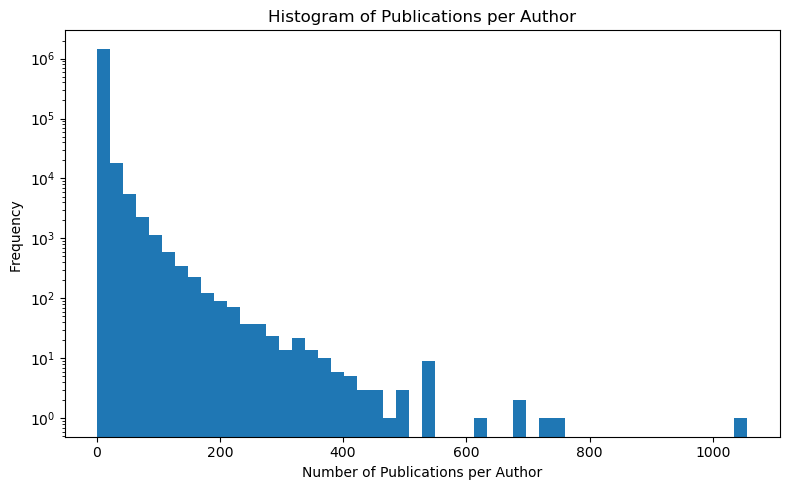

In [13]:
publications_count_per_author = publications_per_author['id'].apply(len)
plt.figure(figsize=(8,5))
plt.hist(publications_count_per_author, bins=50, log=True)
plt.xlabel('Number of Publications per Author')
plt.ylabel('Frequency ')
plt.title('Histogram of Publications per Author')
plt.tight_layout()
plt.show()


# 3.2 b. Quartile calculations

In [14]:
mean_author = publications_count_per_author.mean()
std_deviation_author  = publications_count_per_author.std(ddof=1)
q1_author = publications_count_per_author.quantile(0.25)
median_author = publications_count_per_author.quantile(0.50)
q3_author = publications_count_per_author.quantile(0.75)
print(f"Mean:  {mean_author:.2f}")
print(f"Std Deviation:   {std_deviation_author:.2f}")
print(f"Q1:    {q1_author}")
print(f"Median:{median_author}")
print(f"Q3:    {q3_author}")

Mean:  3.28
Std Deviation:   8.83
Q1:    1.0
Median:1.0
Q3:    2.0


## The mean is more than 3x higher than the median. If we see between quartiles, then median to q3 is only 1 difference.
## The standard deviation is also very high at 8.83.
## All this to me seems to be pointing to very few writers who wrote a lot and got published a lot and hence skewed the data.
## Also it seems majority of authors have only 1 paper contribution.

3.2 c. publications per venue

In [16]:
df_venue = df_papers[df_papers['publication_venue'].astype(str).str.strip() != '']
publication_count_per_venue = (
    df_venue.groupby('publication_venue')['id']
            .nunique()
            .sort_values(ascending=False)
)

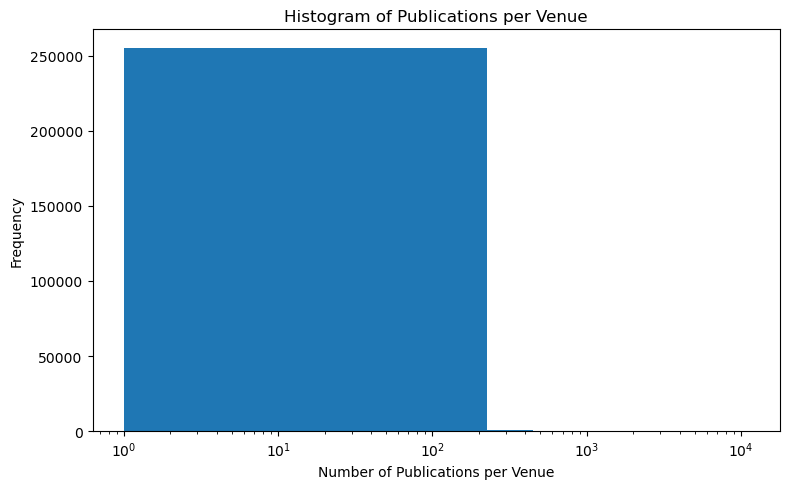

In [17]:
plt.figure(figsize=(8,5))
plt.hist(publication_count_per_venue, bins=50)
plt.xscale('log')
plt.xlabel('Number of Publications per Venue')
plt.ylabel('Frequency')
plt.title('Histogram of Publications per Venue')
plt.tight_layout()
plt.show()

In [18]:
mean_venue = publication_count_per_venue.mean()
std_deviation_venue = publication_count_per_venue.std(ddof=1)
q1_venue = publication_count_per_venue.quantile(0.25)
median_venue = publication_count_per_venue.quantile(0.50)
q3_venue     = publication_count_per_venue.quantile(0.75)

top_venue = publication_count_per_venue.idxmax()
top_venue_total_count = publication_count_per_venue.max()

print(f"Mean: {mean_venue:.2f}")
print(f"Std Deviation: {std_deviation_venue:.2f}")
print(f"Q1: {q1_venue}")
print(f"Median (Q2): {median_venue}")
print(f"Q3: {q3_venue}")
print(f"Top venue: '{top_venue}' with {top_venue_total_count} publications")

Mean: 7.73
Std Deviation: 83.38
Q1: 1.0
Median (Q2): 1.0
Q3: 1.0
Top venue: 'IEEE Transactions on Information Theory' with 11227 publications


# 3.3 a. Histogram of references to a paper to the number of citations in the paper

In [19]:
number_of_references = df_papers['citations'].apply(len)
df_cited = df_papers[['id', 'citations']].explode('citations').dropna(subset=['citations'])
citations_per_paper = df_cited.groupby('citations')['id'].count().rename('num_citations')
df_references_citations_combined = pd.DataFrame({
    'id': df_papers['id'],
    'num_references': number_of_references,
    'num_citations': citations_per_paper
})

In [20]:
df_references_citations_combined['num_citations'] = df_references_citations_combined['num_citations'].fillna(0).astype(int)

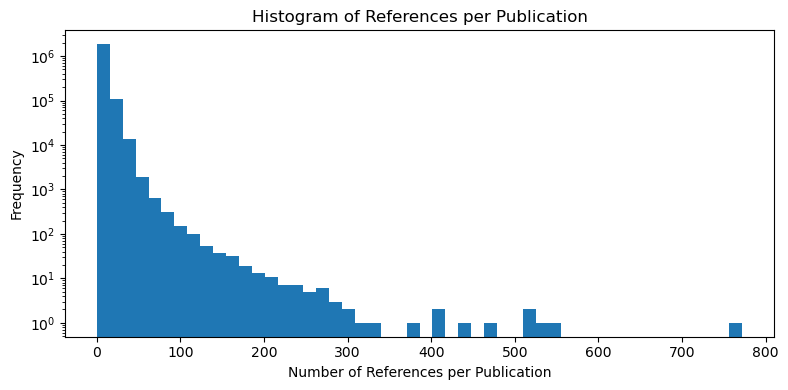

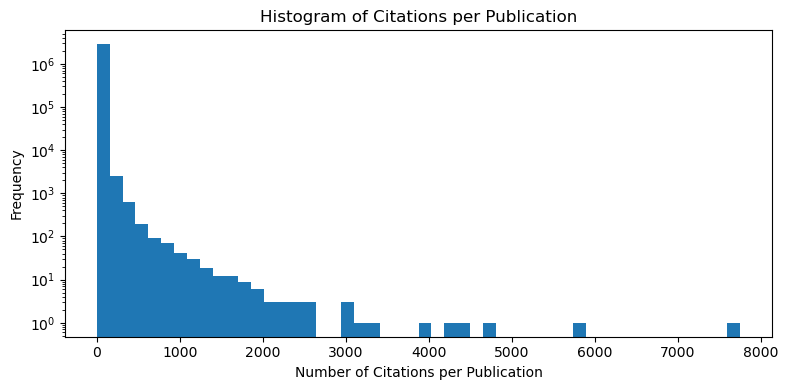

In [21]:
plt.figure(figsize=(8,4))
plt.hist(df_references_citations_combined['num_references'], bins=50, log=True)
plt.xlabel('Number of References per Publication')
plt.ylabel('Frequency')
plt.title('Histogram of References per Publication')
plt.tight_layout()
plt.show()

# Histogram of number of citations per publication
plt.figure(figsize=(8,4))
plt.hist(df_references_citations_combined['num_citations'], bins=50, log=True)
plt.xlabel('Number of Citations per Publication')
plt.ylabel('Frequency')
plt.title('Histogram of Citations per Publication')
plt.tight_layout()
plt.show()

In [22]:
max_refer_row = df_references_citations_combined.loc[df_references_citations_combined['num_references'].idxmax()]
print("Most references:")
print(f"ID: {max_refer_row['id']}, References: {max_refer_row['num_references']}")


max_cited_row = df_references_citations_combined.loc[df_references_citations_combined['num_citations'].idxmax()]
print("\nMost citations:")
print(f"ID: {max_cited_row['id']}, Citations: {max_cited_row['num_citations']}")

Most references:
ID: 719353.0, References: 772.0

Most citations:
ID: nan, Citations: 7753.0


## To me the most references looks normal, but the most cited paper was actually not part of the list of publications

# 3.3 b, c and d Impact factor and venue with highest impact factor

In [24]:
#part b

In [25]:
dfv = df_papers.assign(venue=df_papers['publication_venue'].astype(str).str.strip())
dfv = dfv[dfv['venue'] != '']

pubs_per_venue = dfv.groupby('venue')['id'].nunique()
id2venue = dict(zip(dfv['id'].astype(str), dfv['venue']))

edges = df_papers[['citations']].explode('citations').dropna()
edges['cited_venue'] = edges['citations'].astype(str).map(id2venue)
edges = edges.dropna(subset=['cited_venue'])
cites_per_venue = edges.groupby('cited_venue').size()

venue_stats = pd.DataFrame({'total_citations': cites_per_venue,'num_pubs': pubs_per_venue}).fillna(0)
venue_stats['impact'] = venue_stats['total_citations'] / venue_stats['num_pubs']

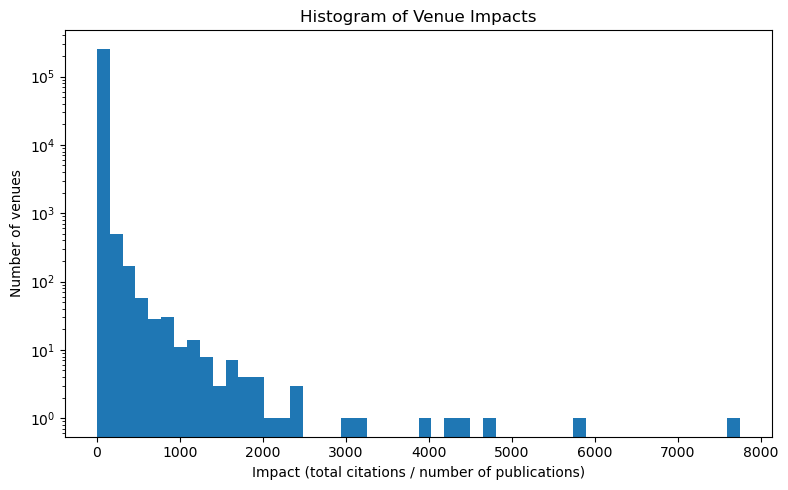

In [26]:
plt.figure(figsize=(8,5))
plt.hist(venue_stats['impact'], bins=50)
plt.yscale('log')
plt.xlabel('Impact (total citations / number of publications)')
plt.ylabel('Number of venues')
plt.title('Histogram of Venue Impacts')
plt.tight_layout()
plt.show()

In [27]:
#part c

In [28]:
top_venue_name = venue_stats['impact'].idxmax()       
top_row = venue_stats.loc[top_venue_name]
print("Highest apparent impact factor:")
print(top_row)

Highest apparent impact factor:
total_citations    7753.0
num_pubs              1.0
impact             7753.0
Name: Computers and Intractability: A Guide to the Theory of NP-Completeness, dtype: float64


In [29]:
# It seems like this venue had just one publication with 7753 citations hence the high impact score.

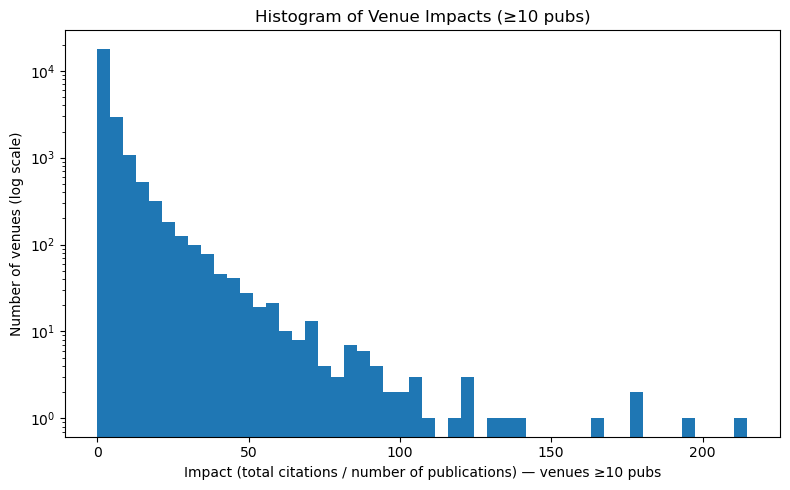

In [30]:
venue_stats_10 = venue_stats[venue_stats['num_pubs'] >= 10]
plt.figure(figsize=(8,5))
plt.hist(venue_stats_10['impact'], bins=50)
plt.yscale('log')
plt.xlabel('Impact (total citations / number of publications) — venues ≥10 pubs')
plt.ylabel('Number of venues (log scale)')
plt.title('Histogram of Venue Impacts (≥10 pubs)')
plt.tight_layout()
plt.show()

In [31]:
# part d

In [32]:
top_venue_name = venue_stats_10['impact'].idxmax()
top_row_10 = venue_stats_10.loc[top_venue_name]
print("Top venue (≥10 pubs):", top_venue_name)
print(top_row_10)

Top venue (≥10 pubs): Proceedings of the 2001 conference on Applications, technologies, architectures, and protocols for computer communications
total_citations    4941.000000
num_pubs             23.000000
impact              214.826087
Name: Proceedings of the 2001 conference on Applications, technologies, architectures, and protocols for computer communications, dtype: float64


In [33]:
per_paper_cites = (
    df_papers[['id','citations']]
      .explode('citations')
      .dropna(subset=['citations'])
      .assign(cited_id=lambda d: d['citations'].astype(str))
      .groupby('cited_id').size()
      .rename('num_citations')
)

dfv2 = dfv.assign(id_str=dfv['id'].astype(str))
papers_in_top = dfv2.loc[dfv2['venue'] == top_venue_name, ['id','publication','id_str']]

papers_with_counts = (
    papers_in_top.merge(per_paper_cites, left_on='id_str', right_index=True, how='left')
                 .fillna({'num_citations': 0})
                 .astype({'num_citations': int})
                 .sort_values('num_citations', ascending=False)
                 .reset_index(drop=True)
)

print(f"\nCitation counts for all publications in '{top_venue_name}':")
print(papers_with_counts[['id','publication','num_citations']])

mean_c   = papers_with_counts['num_citations'].mean()
median_c = papers_with_counts['num_citations'].median()
print(f"\nFor '{top_venue_name}': mean (impact) = {mean_c:.3f}, median = {median_c:.3f}")

print("Reported impact in table:", float(top_row_10['impact']))


Citation counts for all publications in 'Proceedings of the 2001 conference on Applications, technologies, architectures, and protocols for computer communications':
        id                                        publication  num_citations
0   340175  Chord: A scalable peer-to-peer lookup service ...           2140
1   340176             A scalable content-addressable network           1609
2   340164                            Hash-based IP traceback            167
3   340168  Enabling conferencing applications on the inte...            138
4   340165  On the effectiveness of route-based packet fil...            115
5   340172  Statistical bandwidth sharing: a study of cong...            112
6   340173  Analysis and design of an adaptive virtual que...            103
7   340177  An investigation of geographic mapping techniq...             87
8   340179                     Scalable packet classification             67
9   340169         IPNL: A NAT-extended internet architecture  

# 3.3 e publication vs publication year

In [40]:

df_year = df_papers[['id','publication','year','citations']].copy()
pubs_by_year = df_year.groupby('year')['publication'].apply(list)

df_year['num_references'] = df_year['citations'].apply(lambda x: len(x) if isinstance(x, list) else 0)
cited_counts = df_papers['citations'].explode().dropna().astype(str).value_counts()
df_year['num_citations'] = df_year['id'].astype(str).map(cited_counts).fillna(0).astype(int)

year_stats = df_year.groupby('year').agg(avg_references=('num_references','mean'), avg_citations=('num_citations','mean')).reset_index().sort_values('year')


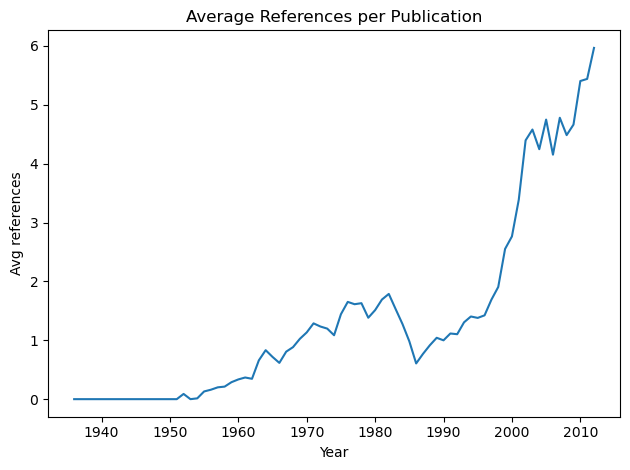

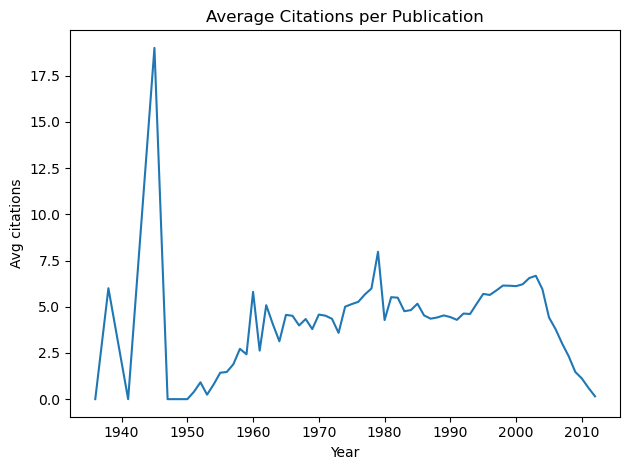

In [41]:
plt.figure()
plt.plot(year_stats['year'], year_stats['avg_references'])
plt.xlabel('Year')
plt.ylabel('Avg references')
plt.title('Average References per Publication')
plt.tight_layout(); plt.show()

plt.figure()
plt.plot(year_stats['year'], year_stats['avg_citations'])
plt.xlabel('Year')
plt.ylabel('Avg citations')
plt.title('Average Citations per Publication')
plt.tight_layout(); plt.show()

## The trend charts show that the references have steadily increased by publication, while average citations by year 